[Exercício 2] Custo Total (Com Penalizações de SLA): 1187.43 ms

RESULTADOS — ALGORITMO GENÉTICO
Melhor rota encontrada: [9 6 7 0 1 2 5 4 3 8]
Custo base da rota: 288.33
Penalidade: 5947.07
Fitness final: 6235.40
Tempo de execução: 1549.92 ms


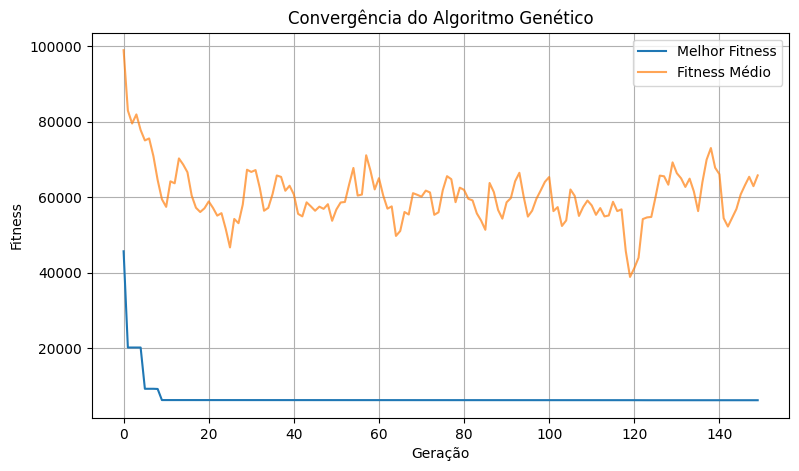

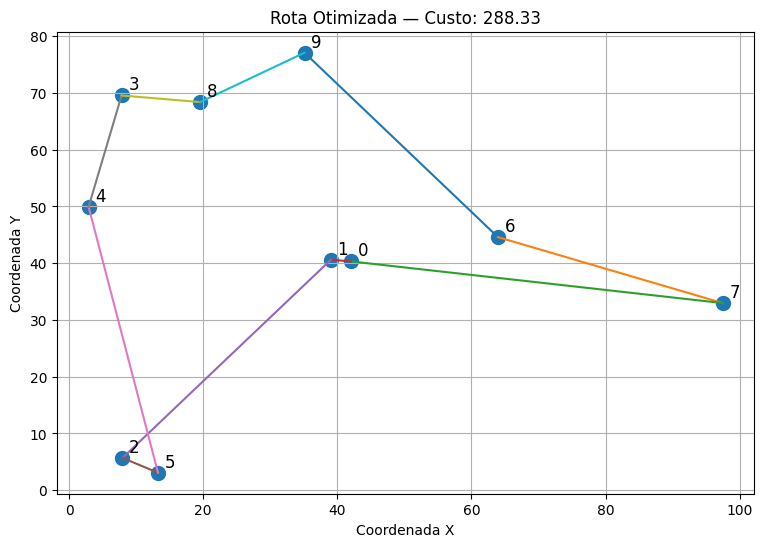

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================
# 1. CONFIGURAÇÕES DO PROBLEMA
# ============================================================

np.random.seed(15); matriz_latencia = np.random.uniform(5, 80, (6, 6)) # Fixed syntax error here

NUM_NOS = 10
TAMANHO_POPULACAO = 60
NUM_GERACOES = 150

TAXA_MUTACAO = 0.20

# Restrição simulada:
# nenhum enlace deve possuir distância superior a este valor
LIMITE_ENLACE = 50.0

# Penalização aplicada para cada violação
PENALIDADE = 1000.0


# ============================================================
# 2. GERAÇÃO DOS NÓS
# ============================================================

# Cada nó possui uma posição X,Y
posicoes_nos = np.random.uniform(
    0,
    100,
    size=(NUM_NOS, 2)
)


# ============================================================
# 3. MATRIZ DE DISTÂNCIAS
# ============================================================

def gerar_matriz_distancias(posicoes):
    """
    Calcula a distância euclidiana entre todos os pares de nós.
    """

    num_nos = len(posicoes)

    matriz = np.zeros((num_nos, num_nos))

    for i in range(num_nos):
        for j in range(num_nos):

            diferenca = posicoes[i] - posicoes[j]

            matriz[i, j] = np.linalg.norm(diferenca)

    return matriz


matriz_distancias = gerar_matriz_distancias(posicoes_nos)


# ============================================================
# 4. FUNÇÃO DE CUSTO DA ROTA (COM SLA)
# ============================================================

def calcular_custo_com_sla(rota, matriz, limite_sla=50.0):
    custo_total = 0.0; penalidade = 0.0 # Fixed syntax error here
    """
    Calcula o custo total de uma rota fechada.

    Exemplo:

    [0, 3, 1, 5]

    representa:

    0 → 3 → 1 → 5 → 0
    """

    # Loop changed to correctly calculate cost for a closed route
    for i in range(len(rota)):
        origem = rota[i]
        destino = rota[(i + 1) % len(rota)]

        latencia_enlace = matriz[origem, destino]
        custo_total += latencia_enlace

        # Incrementa a penalidade caso a latência do enlace ultrapasse o SLA
        if latencia_enlace > limite_sla:
            penalidade += 1000.0

    return custo_total + penalidade

# User's added exercise code
rota_teste = np.array([0, 1, 2, 3, 4, 5])
custo_final_exercicio = calcular_custo_com_sla(rota_teste, matriz_latencia)
print(f"[Exercício 2] Custo Total (Com Penalizações de SLA): {custo_final_exercicio:.2f} ms")


# ============================================================
# 4.1. FUNÇÃO DE CUSTO DA ROTA (BASE)
# ============================================================
# This function is required by calcular_fitness, but was missing.
def calcular_custo_rota(rota, matriz):
    """
    Calcula o custo total de uma rota fechada sem penalidades.
    """
    custo = 0.0
    for i in range(len(rota)):
        origem = rota[i]
        destino = rota[(i + 1) % len(rota)]
        custo += matriz[origem, destino]
    return custo


# ============================================================
# 5. FUNÇÃO DE PENALIZAÇÃO
# ============================================================

def calcular_penalidade(rota, matriz, limite_enlace, penalidade):
    """
    Aplica penalização quando algum enlace da rota
    ultrapassa o limite permitido.
    """

    total_penalidade = 0.0

    for i in range(len(rota)):

        origem = rota[i]

        destino = rota[
            (i + 1) % len(rota)
        ]

        distancia = matriz[origem, destino]

        if distancia > limite_enlace:

            violacao = distancia - limite_enlace

            total_penalidade += penalidade * violacao

    return total_penalidade


# ============================================================
# 6. FUNÇÃO FITNESS
# ============================================================

def calcular_fitness(
    rota,
    matriz,
    limite_enlace,
    penalidade
):
    """
    Fitness = Custo Base + Penalizações

    Como estamos minimizando o problema,
    quanto menor o fitness, melhor.
    """

    custo_base = calcular_custo_rota(
        rota,
        matriz
    )

    multa = calcular_penalidade(
        rota,
        matriz,
        limite_enlace,
        penalidade
    )

    fitness = custo_base + multa

    return fitness


# ============================================================
# 7. CROSSOVER OX
# ============================================================

def crossover_ox(pai1, pai2):
    """
    Ordered Crossover (OX).

    Preserva a validade da permutação.
    """

    tamanho = len(pai1)

    filho = np.full(
        tamanho,
        -1,
        dtype=int
    )

    # Escolha dos pontos de corte
    ponto1, ponto2 = sorted(
        np.random.choice(
            tamanho,
            2,
            replace=False
        )
    )

    # Copia segmento do Pai 1
    filho[ponto1:ponto2] = pai1[ponto1:ponto2]

    # Posição inicial para preenchimento
    posicao = ponto2

    # Percorre Pai 2
    for elemento in pai2:

        # Ignora elementos já existentes
        if elemento not in filho:

            # Retorna ao início quando chega ao final
            if posicao >= tamanho:
                posicao = 0

            filho[posicao] = elemento

            posicao += 1

    return filho


# ============================================================
# 8. MUTAÇÃO SWAP
# ============================================================

def mutacao_swap(rota, taxa_mutacao):
    """
    Troca aleatoriamente duas posições da rota.
    """

    rota = rota.copy()

    if np.random.rand() < taxa_mutacao:

        idx1, idx2 = np.random.choice(
            len(rota),
            2,
            replace=False
        )

        rota[idx1], rota[idx2] = (
            rota[idx2],
            rota[idx1]
        )

    return rota


# ============================================================
# 9. SELEÇÃO POR TORNEIO
# ============================================================

def selecao_torneio(populacao, fitness, tamanho_torneio=2):
    """
    Seleciona um indivíduo através de um torneio.

    Como estamos minimizando:
    menor fitness = vencedor.
    """

    participantes = np.random.choice(
        len(populacao),
        tamanho_torneio,
        replace=False
    )

    melhor = participantes[
        np.argmin(
            [fitness[i] for i in participantes]
        )
    ]

    return populacao[melhor]


# ============================================================
# 10. CRIAÇÃO DA POPULAÇÃO INICIAL
# ============================================================

def criar_populacao(tamanho_populacao, num_nos):

    return [
        np.random.permutation(num_nos)
        for _ in range(tamanho_populacao)
    ]


populacao = criar_populacao(
    TAMANHO_POPULACAO,
    NUM_NOS
)


# ============================================================
# 11. HISTÓRICO DA EVOLUÇÃO
# ============================================================

historico_melhor = []
historico_medio = []


# Melhor solução global
melhor_rota_global = None
melhor_fitness_global = np.inf


# ============================================================
# 12. EXECUÇÃO DO ALGORITMO GENÉTICO
# ============================================================

tempo_inicio = time.time()


for geracao in range(NUM_GERACOES):

    # --------------------------------------------------------
    # Avaliação da população
    # --------------------------------------------------------

    fitness_populacao = [
        calcular_fitness(
            individuo,
            matriz_distancias,
            LIMITE_ENLACE,
            PENALIDADE
        )
        for individuo in populacao
    ]

    # --------------------------------------------------------
    # Melhor indivíduo da geração
    # --------------------------------------------------------

    indice_melhor = np.argmin(
        fitness_populacao
    )

    melhor_rota_geracao = (
        populacao[indice_melhor].copy()
    )

    melhor_fitness_geracao = (
        fitness_populacao[indice_melhor]
    )

    # --------------------------------------------------------
    # Atualização do melhor indivíduo global
    # --------------------------------------------------------

    if melhor_fitness_geracao < melhor_fitness_global:

        melhor_fitness_global = (
            melhor_fitness_geracao
        )

        melhor_rota_global = (
            melhor_rota_geracao.copy()
        )

    # --------------------------------------------------------
    # Histórico
    # --------------------------------------------------------

    historico_melhor.append(
        melhor_fitness_global
    )

    historico_medio.append(
        np.mean(fitness_populacao)
    )

    # --------------------------------------------------------
    # Elitismo
    # --------------------------------------------------------

    nova_populacao = [
        melhor_rota_global.copy()
    ]

    # --------------------------------------------------------
    # Reprodução
    # --------------------------------------------------------

    while len(nova_populacao) < TAMANHO_POPULACAO:

        # Seleção
        pai1 = selecao_torneio(
            populacao,
            fitness_populacao
        )

        pai2 = selecao_torneio(
            populacao,
            fitness_populacao
        )

        # Crossover
        filho = crossover_ox(
            pai1,
            pai2
        )

        # Mutação
        filho = mutacao_swap(
            filho,
            TAXA_MUTACAO
        )

        # Inserção na nova população
        nova_populacao.append(
            filho
        )

    # --------------------------------------------------------
    # Substituição da população
    # --------------------------------------------------------

    populacao = nova_populacao


tempo_fim = time.time()


# ============================================================
# 13. AVALIAÇÃO DA SOLUÇÃO FINAL
# ============================================================

custo_final = calcular_custo_rota(
    melhor_rota_global,
    matriz_distancias
)

penalidade_final = calcular_penalidade(
    melhor_rota_global,
    matriz_distancias,
    LIMITE_ENLACE,
    PENALIDADE
)

fitness_final = (
    custo_final +
    penalidade_final
)


tempo_execucao = (
    tempo_fim - tempo_inicio
) * 1000


# ============================================================
# 14. RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("RESULTADOS — ALGORITMO GENÉTICO")
print("=" * 60)

print(
    f"Melhor rota encontrada: "
    f"{melhor_rota_global}"
)

print(
    f"Custo base da rota: "
    f"{custo_final:.2f}"
)

print(
    f"Penalidade: "
    f"{penalidade_final:.2f}"
)

print(
    f"Fitness final: "
    f"{fitness_final:.2f}"
)

print(
    f"Tempo de execução: "
    f"{tempo_execucao:.2f} ms"
)

print("=" * 60)


# ============================================================
# 15. GRÁFICO DE CONVERGÊNCIA
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    historico_melhor,
    label="Melhor Fitness"
)

plt.plot(
    historico_medio,
    label="Fitness Médio",
    alpha=0.7
)

plt.title(
    "Convergência do Algoritmo Genético"
)

plt.xlabel("Geração")

plt.ylabel("Fitness")

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 16. VISUALIZAÇÃO DA ROTA
# ============================================================

plt.figure(figsize=(9, 6))

# Desenha os nós
plt.scatter(
    posicoes_nos[:, 0],
    posicoes_nos[:, 1],
    s=100
)

# Identificação dos nós
for i, (x, y) in enumerate(posicoes_nos):

    plt.text(
        x + 1,
        y + 1,
        str(i),
        fontsize=12
    )


# Desenha a rota
for i in range(NUM_NOS):

    origem = melhor_rota_global[i]

    destino = melhor_rota_global[
        (i + 1) % NUM_NOS
    ]

    plt.plot(
        [
            posicoes_nos[origem, 0],
            posicoes_nos[destino, 0]
        ],
        [
            posicoes_nos[origem, 1],
            posicoes_nos[destino, 1]
        ]
    )


plt.title(
    f"Rota Otimizada — "
    f"Custo: {custo_final:.2f}"
)

plt.xlabel("Coordenada X")

plt.ylabel("Coordenada Y")

plt.grid(True)

plt.show()